Modelling and simulating the impact of articles

# Libraries

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

In [5]:
from sklearn.metrics import  r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression, ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

In [6]:
data = pd.read_parquet("data_pharmacology/works_modelling.parquet")
data["isintop"] = data["mncs"] > data["mncs"].quantile(0.9)

# Preprocessing

In [7]:
X = data.drop(columns=["mncs", "isintop"])
y_true = data["mncs"]
numeric_features = [
    "mean_past_contributions_authors",
    "mean_past_contributions_institutions",
    "past_contributions_topic",
    "mean_past_mncs_authors",
    "mean_past_mncs_institutions",
    "mean_past_mncs_topic",
    "authors_count",
    "countries_distinct_count",
    "referenced_works_count",
    "institutions_distinct_count",
    "year"
]
categorical_features = [
    "review",
    "meta_analysis"
]

In [8]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])
categorical_transformer= Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

In [9]:
preprocessing = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical_features", categorical_transformer, categorical_features)
] )

# Linear Regression

## _test on the training data_

In [43]:
pipeline_linear = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("regressor", LinearRegression())
])

In [44]:
pipeline_linear.fit(X=X,y=y_true)
y_pred = pipeline_linear.predict(X=X)

In [45]:
print(f"R2: {r2_score(y_pred = y_pred, y_true = y_true)}")
print(f"RMSE: {root_mean_squared_error(y_pred = y_pred, y_true = y_true)}")

R2: 0.07612514100222201
RMSE: 3.2718028766873632


## _cross validation_

In [48]:
cv = KFold(n_splits=5, shuffle=True, random_state=1)

In [49]:
mean_r2_cv = cross_val_score(pipeline_linear, X=X, y=y_true, cv=cv , scoring="r2").mean()
mean_rmse_cv = -cross_val_score(pipeline_linear, X=X, y=y_true, cv=cv, scoring="neg_root_mean_squared_error").mean()

In [50]:
print(f"R2: {mean_r2_cv}")
print(f"RMSE: {mean_rmse_cv}")

R2: 0.06429482881947761
RMSE: 3.2146048032164165


## _feature selection_

In [ ]:
n_features = 6
model = LinearRegression()
pipeline_linear_rfe = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("feature_selection", RFE(model, n_features_to_select=n_features)),
    ("model", model)
])
mean_r2_cv = cross_val_score(pipeline_linear_rfe, X=X, y=y_true, cv=cv, scoring="r2").mean()
mean_rmse_cv = -cross_val_score(pipeline_linear_rfe, X=X, y=y_true, cv=cv, scoring="neg_root_mean_squared_error").mean()

In [ ]:
mean_r2_cv = cross_val_score(pipeline_linear_rfe, X=X, y=y_true, cv=cv, scoring="r2").mean()
mean_rmse_cv = -cross_val_score(pipeline_linear_rfe, X=X, y=y_true, cv=cv, scoring="neg_root_mean_squared_error").mean()

In [56]:
print(f"R2: {mean_r2_cv}")
print(f"RMSE: {mean_rmse_cv}")

R2: 0.06203926138474876
RMSE: 3.2181420615814273


In [ ]:
pipeline_linear_rfe.fit(X=X, y=y_true)
rfe_step = pipeline_linear_rfe.named_steps['feature_selection']
feature_names = pipeline_linear_rfe.named_steps['preprocessing'].get_feature_names_out()

ranking_features = pd.DataFrame({
    'feature': feature_names,
    'ranking': rfe_step.ranking_,
    'selected': rfe_step.support_
}).sort_values('ranking')

print(ranking_features)

                                          feature  ranking  selected
3                 numeric__mean_past_mncs_authors        1      True
4            numeric__mean_past_mncs_institutions        1      True
5                   numeric__mean_past_mncs_topic        1      True
8                 numeric__referenced_works_count        1      True
10                                  numeric__year        1      True
12              categorical_features__review_True        1      True
7               numeric__countries_distinct_count        2     False
11             categorical_features__review_False        3     False
6                          numeric__authors_count        4     False
0        numeric__mean_past_contributions_authors        5     False
14       categorical_features__meta_analysis_True        6     False
9            numeric__institutions_distinct_count        7     False
2               numeric__past_contributions_topic        8     False
13      categorical_features__meta

# ElasticNet regression

## Manual nested cross_validation

In [ ]:
model = ElasticNet()

pipeline_elasticnet = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("model", model)
])

param_grid = {
    "model__alpha": np.logspace(-2, 3, 3),
    "model__l1_ratio": np.linspace(0, 1, 3)
}

inner_cv = KFold(n_splits=3, shuffle=True, random_state=1) #validation (tuning)
outer_cv = KFold(n_splits=3, shuffle=True, random_state=2) #test 

tuned_model = GridSearchCV(pipeline_elasticnet, param_grid, cv=inner_cv, scoring="neg_mean_squared_error")

mse = - cross_val_score(tuned_model, X, y_true, cv=outer_cv, scoring="neg_mean_squared_error").mean()
r2 = cross_val_score(tuned_model, X, y_true, cv=outer_cv, scoring="r2").mean()

## Automatic Nested Cross Validation

In [76]:
model = ElasticNetCV(cv=5, l1_ratio=[0.1,0.5,0.9], alphas=[0.01, 0.1, 1])
pipeline_elasticnet_cv = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("model", model)
])

In [77]:
mean_r2_cv = cross_val_score(pipeline_elasticnet_cv, X=X, y=y_true, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="r2").mean()
mean_rmse_cv = -cross_val_score(pipeline_elasticnet_cv, X=X, y=y_true, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring="neg_root_mean_squared_error").mean()
print(f"R2: {mean_r2_cv}")
print(f"RMSE: {mean_rmse_cv}")

R2: 0.07304738137041619
RMSE: 3.1723070818692314


# PCA

In [95]:
numeric_data = data[numeric_features]

In [96]:
pca = sklearn.decomposition.PCA()

pipeline_pca = Pipeline(steps=[
    ("preprocessing", numeric_transformer),
    ("pca", pca)
])

pipeline_pca.fit(numeric_data)
data_pca = pd.DataFrame(pipeline_pca.transform(numeric_data))
data_pca["isintop"] = data["isintop"]

In [97]:
pca_step = pipeline_pca.named_steps['pca']

components = pca_step.components_
features = numeric_data.columns

cos2 = components.T ** 2  # shape: (n_features, n_components)
cos2_df = pd.DataFrame(cos2, index=features, columns=[f'PC{i+1}' for i in range(pca_step.n_components_)])

contrib = (components.T ** 2) * 100
for i in range(contrib.shape[1]):
    total = contrib[:, i].sum()
    contrib[:, i] = contrib[:, i] / total * 100  

contrib_df = pd.DataFrame(contrib, index=features, columns=[f'PC{i+1}' for i in range(pca_step.n_components_)])


In [98]:
contrib_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
mean_past_contributions_authors,0.042491,10.444812,8.188388,32.334783,31.201103,9.212336,5.238246,1.385620,0.012514,1.919366,0.020341
mean_past_contributions_institutions,9.691338,2.005083,10.049032,1.055182,2.627810,1.943822,41.191309,24.001975,1.140152,6.292531,0.001766
past_contributions_topic,8.125462,25.155523,0.006597,4.715361,0.264071,1.532743,0.363834,35.059424,12.402869,12.290231,0.083884
mean_past_mncs_authors,0.019784,6.498458,23.363414,13.971406,1.130434,54.382401,0.022504,0.058197,0.262507,0.289189,0.001706
mean_past_mncs_institutions,0.118140,1.017671,26.026262,18.292649,26.638597,26.165398,0.351311,1.223290,0.106383,0.059797,0.000502
mean_past_mncs_topic,0.197865,30.570266,6.839999,25.628315,1.120684,0.817365,4.760665,26.880682,2.038944,1.097555,0.047660
authors_count,16.008653,3.537628,6.927121,0.153147,4.793725,0.881493,1.694812,1.782515,46.321773,13.376922,4.522212
countries_distinct_count,20.034952,6.982009,1.946176,0.002873,1.867989,0.159425,3.489755,2.087438,23.899335,2.081642,37.448405
referenced_works_count,7.559543,0.038261,10.239597,1.069645,25.486293,4.470789,40.367135,0.959256,2.843272,6.945750,0.020459
institutions_distinct_count,21.959020,6.429782,3.685799,0.001480,3.672079,0.385936,1.172846,1.297609,3.334491,0.243989,57.816970


In [99]:
cos2_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
mean_past_contributions_authors,0.000425,0.104448,0.081884,0.323348,0.312011,0.092123,0.052382,0.013856,0.000125,0.019194,0.000203
mean_past_contributions_institutions,0.096913,0.020051,0.100490,0.010552,0.026278,0.019438,0.411913,0.240020,0.011402,0.062925,0.000018
past_contributions_topic,0.081255,0.251555,0.000066,0.047154,0.002641,0.015327,0.003638,0.350594,0.124029,0.122902,0.000839
mean_past_mncs_authors,0.000198,0.064985,0.233634,0.139714,0.011304,0.543824,0.000225,0.000582,0.002625,0.002892,0.000017
mean_past_mncs_institutions,0.001181,0.010177,0.260263,0.182926,0.266386,0.261654,0.003513,0.012233,0.001064,0.000598,0.000005
mean_past_mncs_topic,0.001979,0.305703,0.068400,0.256283,0.011207,0.008174,0.047607,0.268807,0.020389,0.010976,0.000477
authors_count,0.160087,0.035376,0.069271,0.001531,0.047937,0.008815,0.016948,0.017825,0.463218,0.133769,0.045222
countries_distinct_count,0.200350,0.069820,0.019462,0.000029,0.018680,0.001594,0.034898,0.020874,0.238993,0.020816,0.374484
referenced_works_count,0.075595,0.000383,0.102396,0.010696,0.254863,0.044708,0.403671,0.009593,0.028433,0.069458,0.000205
institutions_distinct_count,0.219590,0.064298,0.036858,0.000015,0.036721,0.003859,0.011728,0.012976,0.033345,0.002440,0.578170


<Axes: >

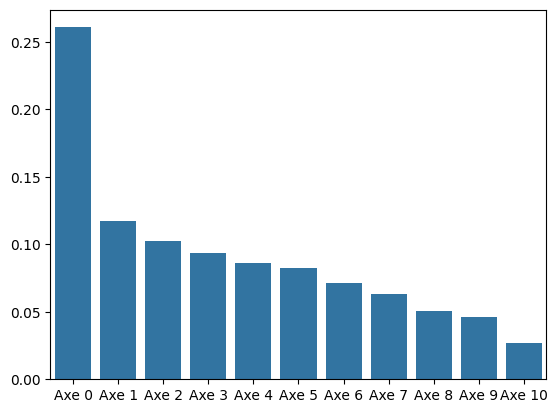

In [100]:
sns.barplot(x = [f"Axe {i}" for i in range(len(pca_step.explained_variance_ratio_))], y = pca_step.explained_variance_ratio_)


<Axes: xlabel='0', ylabel='1'>

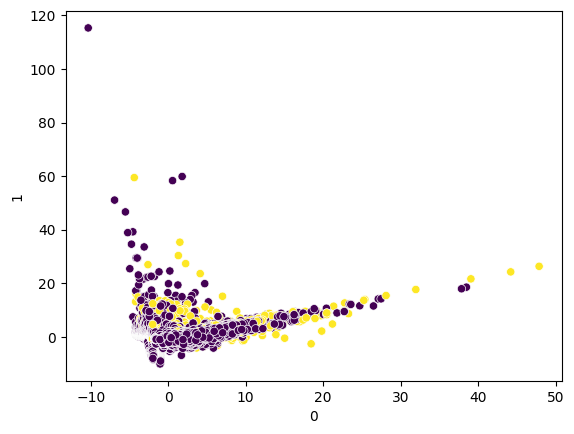

In [101]:
sns.scatterplot(x = data_pca.iloc[:,0], y = data_pca.iloc[:,1], c=data_pca["isintop"])

# Logistic classification on the PCA

### Simple 

In [107]:
train, test = sklearn.model_selection.train_test_split(data_pca)

logistic = sklearn.linear_model.LogisticRegression()
pipeline_logistic = Pipeline(steps=[
    ("preprocessing", numeric_transformer),
    ("model", logistic)
])

pipeline_logistic.fit(X = train.iloc[:,:2], y = train["isintop"])
y_pred = pipeline_logistic.predict(test.iloc[:,:2])
y_true = test["isintop"]

In [108]:
f1 = sklearn.metrics.f1_score(y_true, y_pred)
accuracy = sklearn.metrics.accuracy_score(y_true, y_pred)
precision = sklearn.metrics.precision_score(y_true, y_pred)
recall = sklearn.metrics.recall_score(y_true, y_pred)

In [109]:
print(f"Accuracy: {accuracy}")
print(f"Precision:{precision}")
print(f"Recall: {recall}")
print(f"F1: {f1}")

Accuracy: 0.897562324871021
Precision:0.32
Recall: 0.0066232998225901835
F1: 0.012977983777520278


Text(0.5, 1.0, 'dataset')

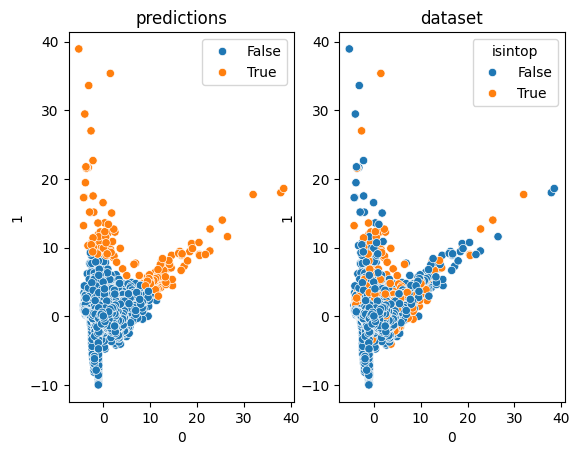

In [110]:
fig, axes = plt.subplot_mosaic([["A","B"]])         
sns.scatterplot(x = test.iloc[:,0], y = test.iloc[:,1], hue=y_pred, ax = axes["A"])
sns.scatterplot(x = test.iloc[:,0], y = test.iloc[:,1], hue=y_true, ax = axes["B"])
axes["A"].set_title("predictions")
axes["B"].set_title("dataset")

### Cross validation

In [111]:
scores = {}
for i in ["accuracy", "precision_macro", "recall_macro", "f1_macro"]:
    score = sklearn.model_selection.cross_val_score(pipeline_logistic, 
                                                    X=data_pca.iloc[:,:2],
                                                    y=data_pca["isintop"],
                                                    scoring=i)
    scores[i] = score.mean()
print(f"Accuracy: {scores["accuracy"]}")
print(f"Precision:{scores["precision_macro"]}")
print(f"Recall: {scores["recall_macro"]}")
print(f"F1: {scores["f1_macro"]}")

Accuracy: 0.8992300226594911
Precision:0.594947674389908
Recall: 0.5027449110369662
F1: 0.4802841855567309


# Random Forest Classification

In [ ]:
random_forest = sklearn.ensemble.RandomForestClassifier(bootstrap=True, random_state=1, class_weight="balanced") # class_weight="balanced" address the class imbalance
pipeline_random_forest = Pipeline(steps=[
    ("preprocessing", numeric_transformer),
    ("model", random_forest)
])

scores = {}
for i in ["accuracy", "precision_macro", "recall_macro", "f1_macro"]:
    score = sklearn.model_selection.cross_val_score(pipeline_random_forest, 
                                                    X=data_pca.iloc[:,:2],
                                                    y=data_pca["isintop"],
                                                    scoring=i)
    scores[i] = score.mean()
print(f"Accuracy: {scores["accuracy"]}")
print(f"Precision:{scores["precision_macro"]}")
print(f"Recall: {scores["recall_macro"]}")
print(f"F1: {scores["f1_macro"]}")

# Boosting Classification

In [ ]:
param_grid = {
    'n_estimators': [20, 50],
    'learning_rate': [0.03, 0.05],
    'max_depth': [3, 2],
    'subsample': [0.8, 0.7]
}

gradient_boosting = GradientBoostingClassifier(random_state=1, class_weight="balanced")
pipeline_gradient_boosting = Pipeline(steps=[
    ("preprocessing", numeric_transformer),
    ("model", gradient_boosting)
])

grid = GridSearchCV(pipeline_gradient_boosting, param_grid, cv=5)
grid.fit(X=data_pca.iloc[:,:2], y=data_pca["isintop"])
print(grid.best_params_)
score = cross_val_score(grid, X=data_pca.iloc[:,:2], y=data_pca["isintop"], scoring="f1_macro").mean()
print(score)

{'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}
